In [1]:
# Install/upgrade TensorFlow (Keras comes built-in with TensorFlow)
# This cell might take 1-2 minutes — that is normal!
!pip install tensorflow --quiet
!pip install Pillow --quiet

print("✅ Libraries installed successfully!")

✅ Libraries installed successfully!


In [2]:
# ── Core Python tools ──────────────────────────────────────────────
import os           # lets us navigate folders on the computer
import numpy as np  # lets us work with arrays of numbers

# ── Image handling ─────────────────────────────────────────────────
from PIL import Image  # lets us open image files

# ── TensorFlow / Keras (neural network tools) ──────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical  # for one-hot encoding

# ── Plotting / visualisation ───────────────────────────────────────
import matplotlib.pyplot as plt

# ── Check TensorFlow version ───────────────────────────────────────
print(f"✅ TensorFlow version: {tf.__version__}")
print(f"✅ Keras version: {tf.keras.__version__}")
print("✅ All libraries imported successfully!")

✅ TensorFlow version: 2.19.0
✅ Keras version: 3.13.2
✅ All libraries imported successfully!


In [3]:
# ── OPTION A: Upload a ZIP file ────────────────────────────────────
# Run this cell if you want to upload a zip file directly

from google.colab import files
import zipfile

print("📂 Please select your dataset ZIP file...")
uploaded = files.upload()  # this opens a file picker dialog

# Get the name of the uploaded file
zip_filename = list(uploaded.keys())[0]
print(f"📦 Uploaded: {zip_filename}")

# Unzip the file
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall('.')  # extracts to current folder

print("✅ Dataset unzipped successfully!")
print("📁 Contents of current folder:")
print(os.listdir('.'))

📂 Please select your dataset ZIP file...


Saving Copy of devnagari digit (1).zip to Copy of devnagari digit (1).zip
📦 Uploaded: Copy of devnagari digit (1).zip
✅ Dataset unzipped successfully!
📁 Contents of current folder:
['.config', 'DevanagariHandwrittenDigitDataset', 'Copy of devnagari digit (1).zip', 'sample_data']


In [4]:
# ── Define where the dataset folders are ───────────────────────────
# If your dataset folder is named differently, change these paths
train_dir = 'DevanagariHandwrittenDigitDataset/Train/'   # folder containing training images
test_dir  = 'DevanagariHandwrittenDigitDataset/Test/'    # folder containing test images

# ── Define the image size ──────────────────────────────────────────
img_height = 28   # height in pixels
img_width  = 28   # width in pixels

# ── Define number of classes ───────────────────────────────────────
# Devnagari digits go from 0 to 9, so there are 10 classes
num_classes = 10

# ── Verify the folders exist ───────────────────────────────────────
if os.path.exists(train_dir):
    print(f"✅ Training folder found: {train_dir}")
    print(f"   Classes found: {sorted(os.listdir(train_dir))}")
else:
    print(f"❌ ERROR: Training folder NOT found at '{train_dir}'")
    print("   Please check your folder name and path above!")

if os.path.exists(test_dir):
    print(f"✅ Test folder found: {test_dir}")
else:
    print(f"❌ ERROR: Test folder NOT found at '{test_dir}'")

✅ Training folder found: DevanagariHandwrittenDigitDataset/Train/
   Classes found: ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']
✅ Test folder found: DevanagariHandwrittenDigitDataset/Test/


In [5]:
def load_images_from_folder(folder):
    """
    This function reads all images from a folder.

    folder: path to the folder (e.g. 'dataset/Train/')
    Returns: images array and labels array
    """
    images = []   # will store all image arrays
    labels = []   # will store all labels (which digit each image is)
    skipped = 0   # count of images we could not read

    # Get the list of class folders (digit_0, digit_1, ... digit_9)
    # sorted() makes sure they are in alphabetical order: digit_0, digit_1, ...
    class_names = sorted(os.listdir(folder))

    # Create a mapping: {'digit_0': 0, 'digit_1': 1, ..., 'digit_9': 9}
    class_map = {name: i for i, name in enumerate(class_names)}
    print(f"📌 Class mapping: {class_map}")

    # Loop through each class folder
    for class_name in class_names:
        class_path = os.path.join(folder, class_name)  # full path to the class folder

        # Skip if it's not a folder (e.g. a stray file)
        if not os.path.isdir(class_path):
            continue

        label = class_map[class_name]  # get the number label for this class

        # Loop through each image file in this class folder
        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)

            try:
                # Step 1: Open the image using PIL
                img = Image.open(img_path)

                # Step 2: Convert to grayscale (black and white)
                # 'L' means luminance = grayscale
                img = img.convert('L')

                # Step 3: Resize to 28x28 pixels
                img = img.resize((img_width, img_height))

                # Step 4: Convert image to a NumPy array of numbers
                img_array = np.array(img)

                # Step 5: Normalise — divide by 255 to get values between 0 and 1
                img_array = img_array / 255.0

                # Add the image and its label to our lists
                images.append(img_array)
                labels.append(label)

            except Exception as e:
                # If an image is corrupted or unreadable, skip it
                skipped += 1

    if skipped > 0:
        print(f"⚠️  Skipped {skipped} unreadable images.")

    # Convert lists to NumPy arrays (required by Keras)
    return np.array(images), np.array(labels)


# ── Load Training Data ─────────────────────────────────────────────
print("\n📂 Loading TRAINING data...")
x_train, y_train_raw = load_images_from_folder(train_dir)
print(f"✅ Training images loaded: {x_train.shape}")
print(f"   Label examples (before encoding): {y_train_raw[:10]}")

# ── Load Test Data ─────────────────────────────────────────────────
print("\n📂 Loading TEST data...")
x_test, y_test_raw = load_images_from_folder(test_dir)
print(f"✅ Test images loaded: {x_test.shape}")


📂 Loading TRAINING data...
📌 Class mapping: {'digit_0': 0, 'digit_1': 1, 'digit_2': 2, 'digit_3': 3, 'digit_4': 4, 'digit_5': 5, 'digit_6': 6, 'digit_7': 7, 'digit_8': 8, 'digit_9': 9}
✅ Training images loaded: (17000, 28, 28)
   Label examples (before encoding): [0 0 0 0 0 0 0 0 0 0]

📂 Loading TEST data...
📌 Class mapping: {'digit_0': 0, 'digit_1': 1, 'digit_2': 2, 'digit_3': 3, 'digit_4': 4, 'digit_5': 5, 'digit_6': 6, 'digit_7': 7, 'digit_8': 8, 'digit_9': 9}
✅ Test images loaded: (3000, 28, 28)


In [6]:
# ── Step 1: Reshape images ─────────────────────────────────────────
# Add the channel dimension: (num_images, 28, 28) → (num_images, 28, 28, 1)
# The -1 means "figure out this dimension automatically"
x_train = x_train.reshape(-1, img_height, img_width, 1)
x_test  = x_test.reshape(-1, img_height, img_width, 1)

print(f"✅ Training images shape after reshape: {x_train.shape}")
print(f"   Reading: ({x_train.shape[0]} images, {x_train.shape[1]}px height, {x_train.shape[2]}px width, {x_train.shape[3]} channel)")
print(f"✅ Test images shape after reshape:     {x_test.shape}")

# ── Step 2: One-hot encode labels ──────────────────────────────────
# to_categorical converts: 3 → [0,0,0,1,0,0,0,0,0,0]
y_train = to_categorical(y_train_raw, num_classes=num_classes)
y_test  = to_categorical(y_test_raw,  num_classes=num_classes)

print(f"\n✅ Training labels shape: {y_train.shape}")
print(f"   Example label (raw): {y_train_raw[0]}")
print(f"   Example label (one-hot): {y_train[0]}")
print(f"✅ Test labels shape: {y_test.shape}")

# ── Step 3: Check pixel value range ───────────────────────────────
print(f"\n📊 Pixel value range — Min: {x_train.min():.2f}, Max: {x_train.max():.2f}")
print("   (Should be 0.0 to 1.0 after normalisation)")

✅ Training images shape after reshape: (17000, 28, 28, 1)
   Reading: (17000 images, 28px height, 28px width, 1 channel)
✅ Test images shape after reshape:     (3000, 28, 28, 1)

✅ Training labels shape: (17000, 10)
   Example label (raw): 0
   Example label (one-hot): [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
✅ Test labels shape: (3000, 10)

📊 Pixel value range — Min: 0.00, Max: 1.00
   (Should be 0.0 to 1.0 after normalisation)


In [7]:
# ── Shuffle training data BEFORE the validation split ──────────────
# This is essential because images were loaded class-by-class:
# all digit_0 first, then digit_1, etc.
# Without shuffling, the first 20% used for validation would only
# contain class 0 → val_accuracy = 0.00% every epoch!

shuffle_indices = np.random.permutation(len(x_train))
x_train = x_train[shuffle_indices]
y_train = y_train[shuffle_indices]

print(f"✅ Training data shuffled!")
print(f"   Shape: {x_train.shape}")
print(f"   First 10 labels after shuffle: {np.argmax(y_train[:10], axis=1)}")
print("   (Labels should now be a mix of different digits, not all 0s)")

✅ Training data shuffled!
   Shape: (17000, 28, 28, 1)
   First 10 labels after shuffle: [2 1 9 8 4 5 4 9 2 7]
   (Labels should now be a mix of different digits, not all 0s)


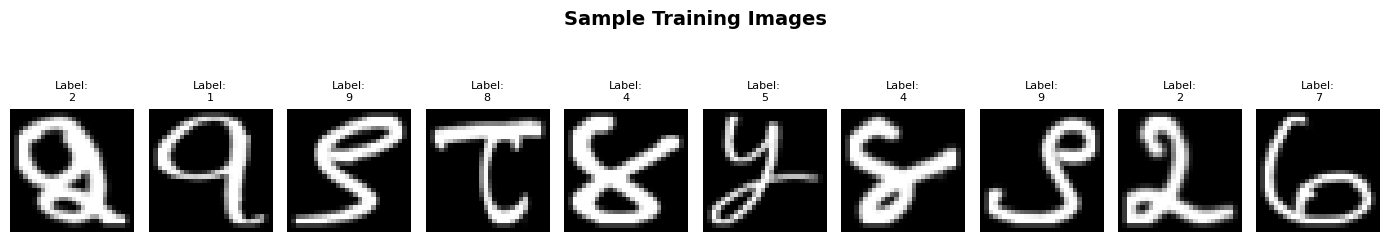

✅ Sample images displayed above. Labels should match what you see!


In [8]:
# Display 10 sample images from the training set
plt.figure(figsize=(14, 3))
plt.suptitle('Sample Training Images', fontsize=14, fontweight='bold')

for i in range(10):
    plt.subplot(1, 10, i + 1)

    # Remove the channel dimension for display: (28,28,1) → (28,28)
    plt.imshow(x_train[i].reshape(img_height, img_width), cmap='gray')

    # Show the label (convert from one-hot back to number using argmax)
    plt.title(f'Label:\n{np.argmax(y_train[i])}', fontsize=8)
    plt.axis('off')  # hide the axes

plt.tight_layout()
plt.show()

print("✅ Sample images displayed above. Labels should match what you see!")

In [10]:
# ── Build the model using the Sequential API ───────────────────────
# Sequential means layers are stacked one after another in a line

model = keras.Sequential(
    [
        # ── Input Layer ──────────────────────────────────────────
        # Tell Keras the shape of one input image: 28 pixels tall, 28 pixels wide, 1 channel
        keras.layers.Input(shape=(img_height, img_width, 1)),

        # ── Flatten Layer ─────────────────────────────────────────
        # Converts 28×28×1 = 784 pixel values into a single list of 784 numbers
        keras.layers.Flatten(),

        # ── Hidden Layer 1 ────────────────────────────────────────
        # 64 neurons, each connected to all 784 inputs
        # sigmoid activation squishes output to between 0 and 1
        keras.layers.Dense(64, activation='sigmoid'),

        # ── Hidden Layer 2 ────────────────────────────────────────
        # 128 neurons, each connected to all 64 outputs from previous layer
        keras.layers.Dense(128, activation='sigmoid'),

        # ── Hidden Layer 3 ────────────────────────────────────────
        # 256 neurons, each connected to all 128 outputs from previous layer
        keras.layers.Dense(256, activation='sigmoid'),

        # ── Output Layer ──────────────────────────────────────────
        # 10 neurons = one for each digit class (0 through 9)
        # softmax makes all 10 outputs add up to 1.0 (like probabilities)
        # e.g. [0.01, 0.02, 0.05, 0.80, 0.02, ...] → the model thinks it is digit 3
        keras.layers.Dense(num_classes, activation='softmax')
    ]
)

# ── Print the model summary ────────────────────────────────────────
# This shows you every layer, its output shape, and how many parameters it has
print("📋 Model Architecture Summary:")
print("=" * 50)
model.summary()
print("\n✅ Model built successfully!")

📋 Model Architecture Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)


✅ Model built successfully!


In [11]:
model.compile(
    optimizer='adam',                  # smart optimiser that adjusts learning speed automatically
    loss='categorical_crossentropy',   # loss function for multi-class problems with one-hot labels
    metrics=['accuracy']               # track accuracy during training
)

print("✅ Model compiled successfully!")
print("   Optimizer  : Adam")
print("   Loss       : Categorical Cross-Entropy")
print("   Metric     : Accuracy")

✅ Model compiled successfully!
   Optimizer  : Adam
   Loss       : Categorical Cross-Entropy
   Metric     : Accuracy


In [12]:
# ── Training Parameters ────────────────────────────────────────────
BATCH_SIZE = 128   # number of images processed before weights are updated
EPOCHS     = 20    # number of times to go through the entire training dataset

# ── Set up Callbacks ───────────────────────────────────────────────
callbacks = [
    # Save the best model (lowest validation loss) automatically
    keras.callbacks.ModelCheckpoint(
        filepath='best_model.keras',   # file to save to
        monitor='val_loss',            # watch validation loss
        save_best_only=True,           # only save if it improved
        verbose=1                      # print a message when saving
    ),

    # Stop training early if validation loss doesn't improve for 5 epochs
    keras.callbacks.EarlyStopping(
        monitor='val_loss',   # watch validation loss
        patience=5,           # wait 5 epochs before stopping
        verbose=1,            # print a message when stopping
        restore_best_weights=True  # go back to the best weights found
    )
]

# ── Train the Model ────────────────────────────────────────────────
print("🚀 Starting training...")
print(f"   Batch size       : {BATCH_SIZE}")
print(f"   Max epochs       : {EPOCHS}")
print(f"   Validation split : 20%")
print("-" * 60)

history = model.fit(
    x_train,              # training images
    y_train,              # training labels (one-hot encoded)
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.2, # use 20% of training data for validation
    callbacks=callbacks,
    verbose=1             # show progress bar for each epoch
)

print("\n✅ Training complete!")

🚀 Starting training...
   Batch size       : 128
   Max epochs       : 20
   Validation split : 20%
------------------------------------------------------------
Epoch 1/20
101/107 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2256 - loss: 2.1947
Epoch 1: val_loss improved from None to 1.03596, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.4233 - loss: 1.8464 - val_accuracy: 0.7632 - val_loss: 1.0360
Epoch 2/20
102/107 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7914 - loss: 0.8101
Epoch 2: val_loss improved from 1.03596 to 0.47703, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8059 - loss: 0.6670 - val_accuracy: 0.8329 - val_loss: 0.4770
Epoch 3/20
105/107 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8705 - loss: 0.4102
Epoch 3: val_loss improved from 0.47703 to 0.33117, saving model to best_mo

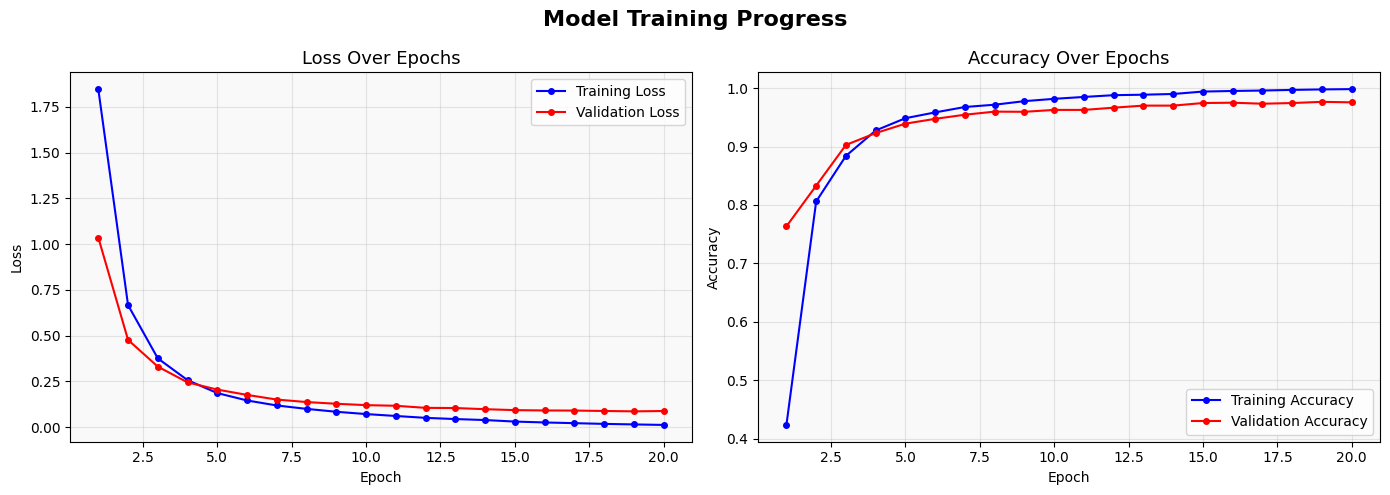


📈 Training Summary:
   Total epochs run       : 20
   Best training accuracy : 0.9982 (99.82%)
   Best validation accuracy: 0.9765 (97.65%)
   Final training loss    : 0.0127
   Final validation loss  : 0.0887


In [13]:
# ── Extract history data ───────────────────────────────────────────
train_loss = history.history['loss']
val_loss   = history.history['val_loss']
train_acc  = history.history['accuracy']
val_acc    = history.history['val_accuracy']

epochs_ran = range(1, len(train_loss) + 1)

# ── Create the plots ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Training Progress', fontsize=16, fontweight='bold')

# --- Plot 1: Loss ---
axes[0].plot(epochs_ran, train_loss, 'b-o', label='Training Loss',   markersize=4)
axes[0].plot(epochs_ran, val_loss,   'r-o', label='Validation Loss', markersize=4)
axes[0].set_title('Loss Over Epochs', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_facecolor('#f9f9f9')

# --- Plot 2: Accuracy ---
axes[1].plot(epochs_ran, train_acc, 'b-o', label='Training Accuracy',   markersize=4)
axes[1].plot(epochs_ran, val_acc,   'r-o', label='Validation Accuracy', markersize=4)
axes[1].set_title('Accuracy Over Epochs', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_facecolor('#f9f9f9')

plt.tight_layout()
plt.show()

# ── Print summary statistics ───────────────────────────────────────
print(f"\n📈 Training Summary:")
print(f"   Total epochs run       : {len(train_loss)}")
print(f"   Best training accuracy : {max(train_acc):.4f} ({max(train_acc)*100:.2f}%)")
print(f"   Best validation accuracy: {max(val_acc):.4f} ({max(val_acc)*100:.2f}%)")
print(f"   Final training loss    : {train_loss[-1]:.4f}")
print(f"   Final validation loss  : {val_loss[-1]:.4f}")

In [14]:
print("🔍 Evaluating model on TEST data (images never seen during training)...")
print("-" * 60)

# Evaluate the model — verbose=2 shows one line per batch
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)

print("-" * 60)
print(f"\n📊 FINAL TEST RESULTS:")
print(f"   Test Loss     : {test_loss:.4f}")
print(f"   Test Accuracy : {test_acc:.4f} ({test_acc * 100:.2f}%)")

# Give a friendly interpretation
if test_acc >= 0.90:
    print("\n🌟 Excellent! The model is performing very well.")
elif test_acc >= 0.75:
    print("\n👍 Good performance! There is some room for improvement.")
else:
    print("\n⚠️  The model needs more training or tuning.")

🔍 Evaluating model on TEST data (images never seen during training)...
------------------------------------------------------------
94/94 - 0s - 4ms/step - accuracy: 0.9787 - loss: 0.0870
------------------------------------------------------------

📊 FINAL TEST RESULTS:
   Test Loss     : 0.0870
   Test Accuracy : 0.9787 (97.87%)

🌟 Excellent! The model is performing very well.


In [15]:
# ── Save the model ─────────────────────────────────────────────────
model_save_path = 'devnagari_fcn_model.h5'
model.save(model_save_path)

# Confirm the file was saved
if os.path.exists(model_save_path):
    file_size_mb = os.path.getsize(model_save_path) / (1024 * 1024)
    print(f"✅ Model saved successfully!")
    print(f"   File: {model_save_path}")
    print(f"   Size: {file_size_mb:.2f} MB")
else:
    print("❌ Something went wrong — file was not saved.")

✅ Model saved successfully!
   File: devnagari_fcn_model.h5
   Size: 1.11 MB


In [16]:
# ── Load the saved model ───────────────────────────────────────────
print("📂 Loading saved model from disk...")
loaded_model = tf.keras.models.load_model(model_save_path)

print("✅ Model loaded successfully!")
print("\n📋 Loaded model architecture:")
loaded_model.summary()

# ── Re-evaluate the loaded model ───────────────────────────────────
print("\n🔍 Re-evaluating the loaded model on test data...")
print("-" * 60)
loaded_loss, loaded_acc = loaded_model.evaluate(x_test, y_test, verbose=2)

print("-" * 60)
print(f"\n📊 LOADED MODEL TEST RESULTS:")
print(f"   Test Loss     : {loaded_loss:.4f}")
print(f"   Test Accuracy : {loaded_acc:.4f} ({loaded_acc * 100:.2f}%)")
print("\n✅ Results should match the previous evaluation!")

📂 Loading saved model from disk...
✅ Model loaded successfully!

📋 Loaded model architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,156 (367.80 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)


🔍 Re-evaluating the loaded model on test data...
------------------------------------------------------------
94/94 - 1s - 7ms/step - accuracy: 0.9787 - loss: 0.0870
------------------------------------------------------------

📊 LOADED MODEL TEST RESULTS:
   Test Loss     : 0.0870
   Test Accuracy : 0.9787 (97.87%)

✅ Results should match the previous evaluation!


In [17]:
# ── Step 1: Get predictions for ALL test images ────────────────────
print("🔮 Making predictions on all test images...")
predictions = model.predict(x_test, verbose=0)

# predictions is an array of shape (num_test_images, 10)
# Each row has 10 probabilities (one per class)
print(f"✅ Predictions shape: {predictions.shape}")
print(f"   Probabilities for first image: {predictions[0].round(3)}")

# ── Step 2: Convert probabilities to class labels ──────────────────
# np.argmax finds the index with the highest value
predicted_labels = np.argmax(predictions, axis=1)  # predicted digits
true_labels      = np.argmax(y_test, axis=1)        # actual digits

print(f"\n🔢 First 10 predictions vs true labels:")
print(f"   Predicted : {predicted_labels[:10]}")
print(f"   True      : {true_labels[:10]}")

🔮 Making predictions on all test images...
✅ Predictions shape: (3000, 10)
   Probabilities for first image: [0.999 0.    0.    0.    0.    0.    0.    0.    0.    0.   ]

🔢 First 10 predictions vs true labels:
   Predicted : [0 0 0 0 0 0 0 0 0 0]
   True      : [0 0 0 0 0 0 0 0 0 0]


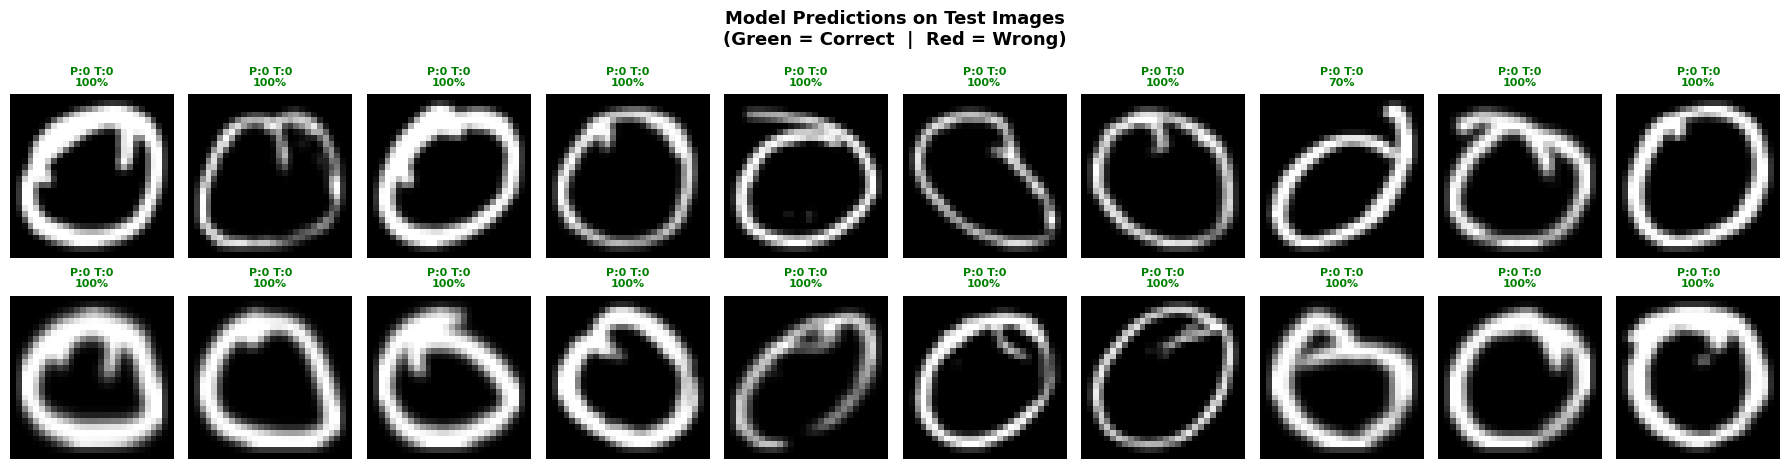


📊 Prediction Summary (all 3000 test images):
   ✅ Correct predictions : 2936
   ❌ Wrong predictions   : 64
   🎯 Accuracy            : 97.87%


In [18]:
# ── Display 20 test images with predictions ────────────────────────
num_display = 20
num_cols    = 10
num_rows    = 2

fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, 5))
fig.suptitle('Model Predictions on Test Images\n(Green = Correct  |  Red = Wrong)',
             fontsize=13, fontweight='bold')

for i in range(num_display):
    row = i // num_cols
    col = i  % num_cols
    ax  = axes[row][col]

    # Display the image
    ax.imshow(x_test[i].reshape(img_height, img_width), cmap='gray')

    pred  = predicted_labels[i]
    truth = true_labels[i]
    conf  = predictions[i][pred] * 100  # confidence percentage

    # Green if correct, red if wrong
    colour = 'green' if pred == truth else 'red'
    ax.set_title(f'P:{pred} T:{truth}\n{conf:.0f}%',
                 fontsize=8, color=colour, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

# ── Count correct and wrong predictions ───────────────────────────
correct = np.sum(predicted_labels == true_labels)
wrong   = len(true_labels) - correct

print(f"\n📊 Prediction Summary (all {len(true_labels)} test images):")
print(f"   ✅ Correct predictions : {correct}")
print(f"   ❌ Wrong predictions   : {wrong}")
print(f"   🎯 Accuracy            : {correct/len(true_labels)*100:.2f}%")

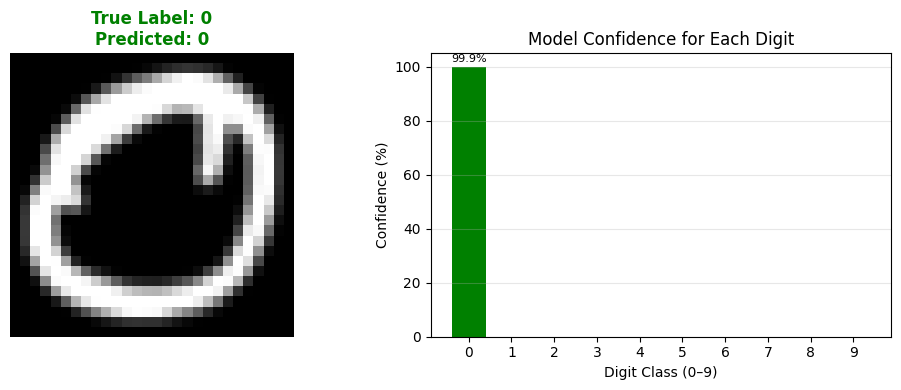


🔍 Detailed Result for Image #0:
   True label      : 0
   Predicted label : 0
   Confidence      : 99.94%
   All probabilities: {0: np.float32(99.9), 1: np.float32(0.0), 2: np.float32(0.0), 3: np.float32(0.0), 4: np.float32(0.0), 5: np.float32(0.0), 6: np.float32(0.0), 7: np.float32(0.0), 8: np.float32(0.0), 9: np.float32(0.0)}


In [19]:
# ── Choose which test image to inspect ────────────────────────────
image_index = 0  # ← change this number to inspect a different image

# Get the single image and its prediction
single_image      = x_test[image_index]
single_pred_probs = predictions[image_index]
single_pred_label = predicted_labels[image_index]
single_true_label = true_labels[image_index]

# ── Create side-by-side plot ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left: Show the image
axes[0].imshow(single_image.reshape(img_height, img_width), cmap='gray')
colour = 'green' if single_pred_label == single_true_label else 'red'
axes[0].set_title(f'True Label: {single_true_label}\nPredicted: {single_pred_label}',
                   fontsize=12, color=colour, fontweight='bold')
axes[0].axis('off')

# Right: Show the probability bar chart
bar_colours = ['green' if i == single_pred_label else 'steelblue' for i in range(num_classes)]
bars = axes[1].bar(range(num_classes), single_pred_probs * 100, color=bar_colours)
axes[1].set_xlabel('Digit Class (0–9)')
axes[1].set_ylabel('Confidence (%)')
axes[1].set_title('Model Confidence for Each Digit')
axes[1].set_xticks(range(num_classes))
axes[1].set_ylim(0, 105)
axes[1].grid(axis='y', alpha=0.3)

# Add percentage labels on top of bars
for i, (bar, prob) in enumerate(zip(bars, single_pred_probs)):
    if prob > 0.01:  # only label bars with > 1% probability
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                     f'{prob*100:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print(f"\n🔍 Detailed Result for Image #{image_index}:")
print(f"   True label      : {single_true_label}")
print(f"   Predicted label : {single_pred_label}")
print(f"   Confidence      : {single_pred_probs[single_pred_label]*100:.2f}%")
print(f"   All probabilities: {dict(zip(range(10), (single_pred_probs*100).round(1)))}")

In [22]:
print(f"""
📦 DATASET
   Training images : {x_train.shape[0]}
   Test images     : {x_test.shape[0]}
   Image size      : {img_height}×{img_width} pixels (grayscale)
   Classes         : {num_classes} (digits 0–9)

🏗️  MODEL ARCHITECTURE
   Layer 1 : Flatten   → 784 inputs
   Layer 2 : Dense(64) + Sigmoid
   Layer 3 : Dense(128) + Sigmoid
   Layer 4 : Dense(256) + Sigmoid
   Layer 5 : Dense(10)  + Softmax  (output)

⚙️  TRAINING SETUP
   Optimizer       : Adam
   Loss function   : Categorical Cross-Entropy
   Batch size      : {BATCH_SIZE}
   Max epochs      : {EPOCHS}
   Actual epochs   : {len(train_loss)}
   Validation split: 20%

📊 RESULTS
   Final Test Loss     : {test_loss:.4f}
   Final Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)

💾 DELIVERABLES
   ✅ Code implementation (this notebook)
   ✅ Training/validation loss and accuracy graphs
   ✅ Test accuracy displayed
   ✅ Saved model: devnagari_fcn_model.h5
   ✅ Predictions visualised
""")



📦 DATASET
   Training images : 17000
   Test images     : 3000
   Image size      : 28×28 pixels (grayscale)
   Classes         : 10 (digits 0–9)

🏗️  MODEL ARCHITECTURE
   Layer 1 : Flatten   → 784 inputs
   Layer 2 : Dense(64) + Sigmoid
   Layer 3 : Dense(128) + Sigmoid
   Layer 4 : Dense(256) + Sigmoid
   Layer 5 : Dense(10)  + Softmax  (output)

⚙️  TRAINING SETUP
   Optimizer       : Adam
   Loss function   : Categorical Cross-Entropy
   Batch size      : 128
   Max epochs      : 20
   Actual epochs   : 20
   Validation split: 20%

📊 RESULTS
   Final Test Loss     : 0.0870
   Final Test Accuracy : 0.9787  (97.87%)

💾 DELIVERABLES
   ✅ Code implementation (this notebook)
   ✅ Training/validation loss and accuracy graphs
   ✅ Test accuracy displayed
   ✅ Saved model: devnagari_fcn_model.h5
   ✅ Predictions visualised

